# Olist E-Commerce Analytics — Phase 3: Complete Time Series Analysis

This notebook continues from **Phase 2: Python EDA**.

In Phase 2, the monthly sales table was created in **Section 12: Monthly Revenue Trend** and exported as:

`reports/monthly_sales_for_time_series.csv`

This Phase 3 notebook performs a complete time series workflow:

1. Load monthly sales data from Phase 2  
2. Prepare monthly revenue series  
3. Visualize trend  
4. Decompose the series  
5. Apply transformation  
6. Check stationarity before and after transformation  
7. Apply differencing if required  
8. Re-check stationarity  
9. Use ACF/PACF  
10. Perform ARIMA grid search  
11. Forecast on transformed scale  
12. Apply inverse transformation  
13. Evaluate forecast accuracy  
14. Generate future forecast  
15. Export results for reporting and Power BI


## 1. Environment Setup

In [1]:
import warnings
from pathlib import Path
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PROJECT_DIR = Path.cwd()
REPORTS_DIR = PROJECT_DIR / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print("Setup completed.")
print("Project directory:", PROJECT_DIR)
print("Reports directory:", REPORTS_DIR)
print("Figures directory:", FIGURES_DIR)

Setup completed.
Project directory: C:\Users\ayush\OneDrive\Desktop\OlistProject
Reports directory: C:\Users\ayush\OneDrive\Desktop\OlistProject\reports
Figures directory: C:\Users\ayush\OneDrive\Desktop\OlistProject\reports\figures


## 2. Load Monthly Sales Data from Phase 2


In [2]:
possible_paths = [
    REPORTS_DIR / "monthly_sales_for_time_series.csv",
    PROJECT_DIR / "monthly_sales_for_time_series.csv"
]

csv_path = None
for path in possible_paths:
    if path.exists():
        csv_path = path
        break

if csv_path is None:
    raise FileNotFoundError(
        "monthly_sales_for_time_series.csv was not found.\n"
        "Run Phase 2 Section 12 first and export the monthly sales CSV."
    )

monthly_sales = pd.read_csv(csv_path)

print("Loaded file:", csv_path)
print("Shape:", monthly_sales.shape)
monthly_sales.head()

Loaded file: C:\Users\ayush\OneDrive\Desktop\OlistProject\reports\monthly_sales_for_time_series.csv
Shape: (23, 8)


,order_month,total_orders,total_revenue,product_revenue,freight_revenue,avg_item_price,avg_order_value,avg_review_score
0,2016-09-01,1,143.46,134.97,8.49,44.99,143.46,1.00
1,2016-10-01,265,"46,490.66","40,325.11","6,165.55",128.83,175.44,4.01
2,2016-12-01,1,19.62,10.90,8.72,10.90,19.62,5.00
3,2017-01-01,750,"127,482.37","111,798.36","15,684.01",122.45,169.98,4.20
4,2017-02-01,1653,"271,239.32","234,223.40","37,015.92",126.06,164.09,4.20


## 3. Prepare Monthly Time Series

We convert `order_month` into datetime and set it as the monthly index.

The early 2016 months contain very few records, so the modelling period starts from **January 2017** for a more stable business trend.


In [3]:
monthly_sales["order_month"] = pd.to_datetime(monthly_sales["order_month"])
monthly_sales = monthly_sales.sort_values("order_month").reset_index(drop=True)

monthly_sales_full = monthly_sales.copy()
monthly_sales = monthly_sales.set_index("order_month")

print("Complete date range:", monthly_sales.index.min().date(), "to", monthly_sales.index.max().date())
print("Complete number of months:", len(monthly_sales))

# Stable modelling period
ts_data = monthly_sales.loc[monthly_sales.index >= "2017-01-01"].copy()

print("Modelling date range:", ts_data.index.min().date(), "to", ts_data.index.max().date())
print("Months used for modelling:", len(ts_data))

ts_data.head()

Complete date range: 2016-09-01 to 2018-08-01
Complete number of months: 23
Modelling date range: 2017-01-01 to 2018-08-01
Months used for modelling: 20


,total_orders,total_revenue,product_revenue,freight_revenue,avg_item_price,avg_order_value,avg_review_score
order_month,,,,,,,
2017-01-01,750,"127,482.37","111,798.36","15,684.01",122.45,169.98,4.20
2017-02-01,1653,"271,239.32","234,223.40","37,015.92",126.06,164.09,4.20
2017-03-01,2546,"414,330.95","359,198.85","55,132.10",123.99,162.74,4.19
2017-04-01,2303,"390,812.40","340,669.68","50,142.72",132.61,169.70,4.14
2017-05-01,3546,"566,851.40","489,338.25","77,513.15",122.21,159.86,4.24


## 4. Select Target Variable

The main target variable is:

`total_revenue`

This is the monthly delivered-order revenue created in Phase 2.


In [4]:
revenue = ts_data["total_revenue"].astype(float)

revenue_summary = pd.DataFrame({
    "metric": ["Start month", "End month", "Total months", "Mean revenue", "Minimum revenue", "Maximum revenue"],
    "value": [
        revenue.index.min(),
        revenue.index.max(),
        len(revenue),
        revenue.mean(),
        revenue.min(),
        revenue.max()
    ]
})

revenue_summary

,metric,value
0,Start month,2017-01-01 00:00:00
1,End month,2018-08-01 00:00:00
2,Total months,20
3,Mean revenue,"768,656.00"
4,Minimum revenue,"127,482.37"
5,Maximum revenue,"1,153,364.20"


## 5. Visualize Original Revenue Series


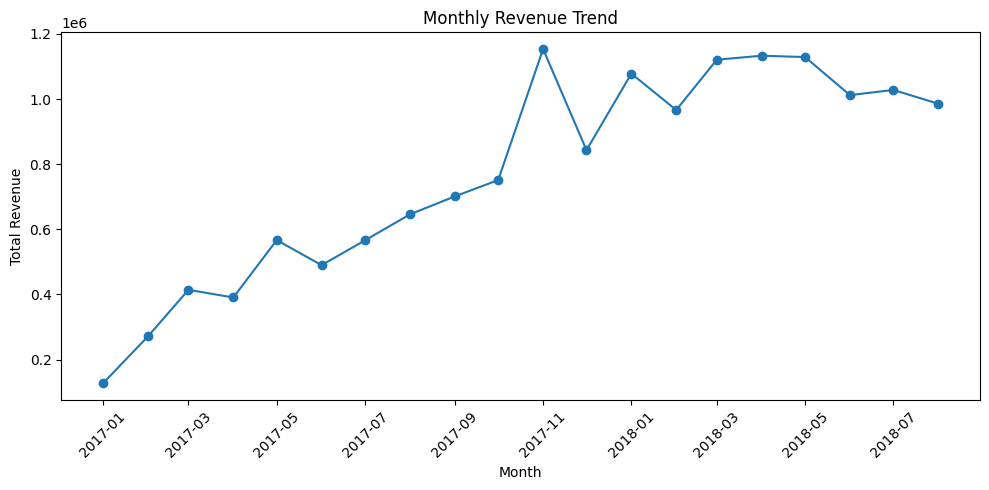

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(revenue.index, revenue.values, marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_original_monthly_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The monthly revenue series shows a clear business trend over time.  
This means we should not directly assume stationarity before testing it.


## 6. Time Series Decomposition

Decomposition separates the series into:

- trend,
- seasonal/cyclical movement,
- and residual noise.

Important note: proper yearly monthly decomposition needs at least **24 months** for two full yearly cycles.  
This dataset has a short monthly history, so we use STL decomposition with a shorter exploratory period.


Decomposition period used: 6


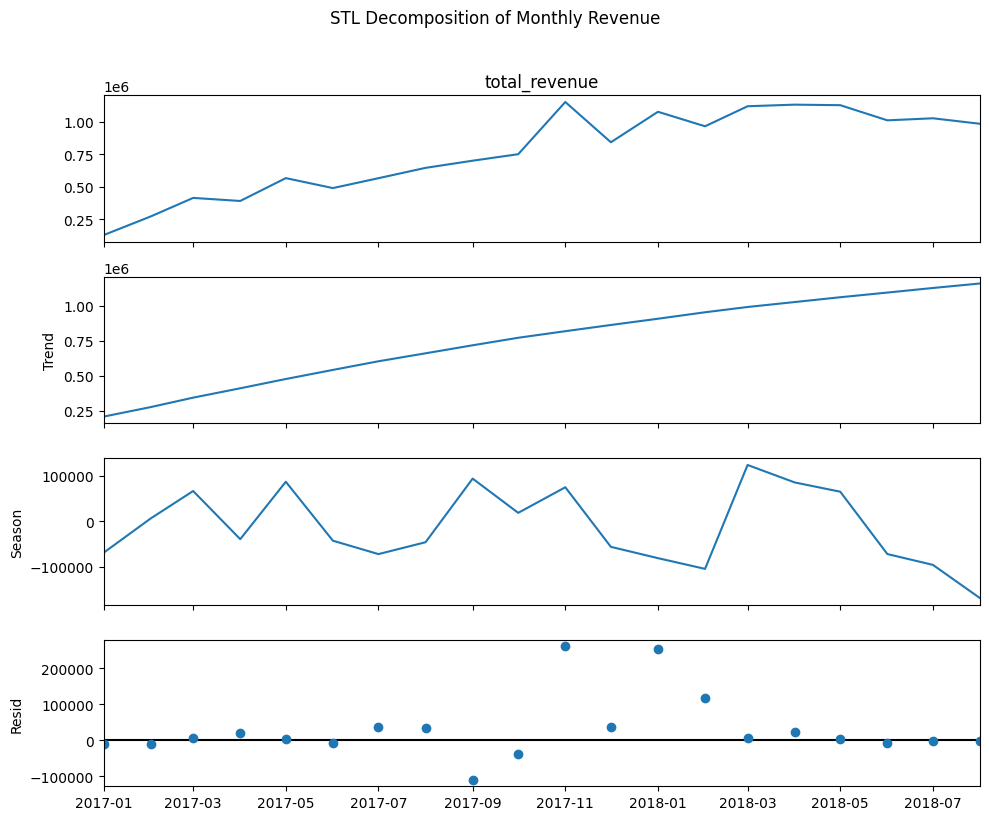

In [6]:
# If at least 24 months are available, period 12 can be used.
# Otherwise, use period 6 as a short-cycle exploratory decomposition.
if len(revenue) >= 24:
    decomposition_period = 12
else:
    decomposition_period = 6

print("Decomposition period used:", decomposition_period)

stl = STL(revenue, period=decomposition_period, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(10, 8)
plt.suptitle("STL Decomposition of Monthly Revenue", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_stl_decomposition_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

The STL decomposition shows that monthly revenue has a clear upward trend over time. This confirms that the original revenue series is not fully stationary and needs further transformation or differencing before ARIMA modelling.

The seasonal component shows short-term fluctuations, but because the dataset contains limited monthly observations, this should be treated as an exploratory pattern rather than strong evidence of yearly seasonality.

The residual component contains a few spikes, indicating months where revenue deviated strongly from the general trend. Such deviations are expected in e-commerce data due to demand fluctuations and high-sales periods.

### Interpretation

The decomposition helps us visually separate the long-term trend from short-term fluctuations.

Because the dataset is short, this decomposition should be treated as exploratory rather than a strong proof of yearly seasonality.


## 7. Stationarity Test on Original Series

ARIMA requires the series to be stationary or made stationary through differencing.

We use the Augmented Dickey-Fuller test:

- p-value < 0.05: stationary  
- p-value >= 0.05: not stationary


In [7]:
def adf_test(series, series_name):
    series = series.dropna()
    result = adfuller(series)

    return {
        "series": series_name,
        "adf_statistic": result[0],
        "p_value": result[1],
        "stationary_at_5_percent": result[1] < 0.05
    }

original_adf = pd.DataFrame([
    adf_test(revenue, "Original revenue")
])

original_adf

,series,adf_statistic,p_value,stationary_at_5_percent
0,Original revenue,-2.27,0.18,False


The ADF test result shows that the original monthly revenue series is not stationary because the p-value is greater than 0.05.

This means the revenue series contains trend or time-dependent structure, so it cannot be directly used for ARIMA modelling in its original form.

Therefore, transformation and differencing are required before building the forecasting model.

## 8. Transformation

Revenue values are usually right-skewed and may have changing variance over time.

We apply log transformation using:

`log1p(x) = log(1 + x)`

This transformation stabilizes variance and keeps the values positive.


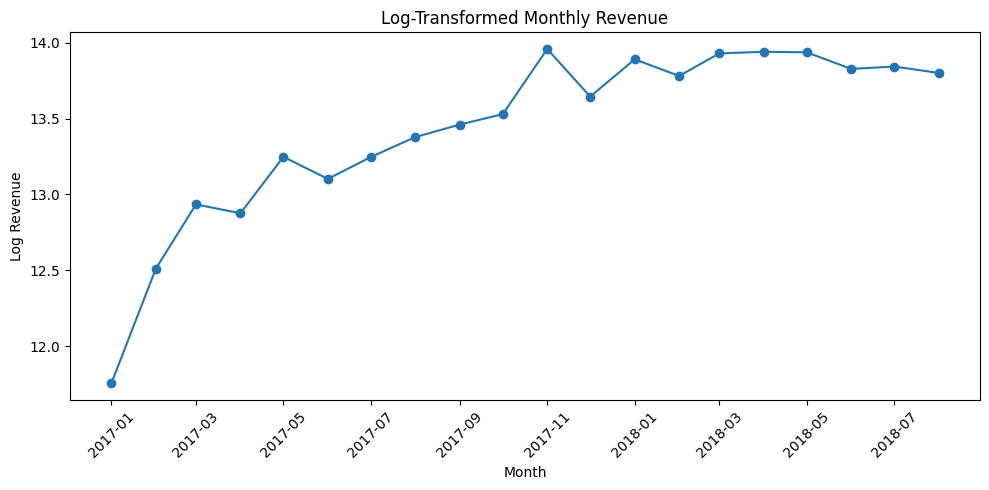

In [8]:
log_revenue = np.log1p(revenue)

plt.figure(figsize=(10, 5))
plt.plot(log_revenue.index, log_revenue.values, marker="o")
plt.title("Log-Transformed Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Log Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_log_transformed_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Stationarity Test After Transformation

After transformation, stationarity must be checked again.

If the transformed series is still non-stationary, differencing is applied.


In [9]:
transformation_adf = pd.DataFrame([
    adf_test(revenue, "Original revenue"),
    adf_test(log_revenue, "Log-transformed revenue")
])

transformation_adf

,series,adf_statistic,p_value,stationary_at_5_percent
0,Original revenue,-2.27,0.18,False
1,Log-transformed revenue,-3.79,0.00,True


Log transformation has made the revenue series stationary.

### Interpretation

The model uses the value of `d` based on the stationarity test.

This is better than directly assuming `d = 0`.


## 11. ACF and PACF Plots

ACF and PACF are used to understand possible values of `p` and `q`.

Since the dataset is short, the number of lags is kept small and safe.


In [10]:
stationary_series = log_revenue
selected_d = 0

safe_lags = max(1, min(8, len(stationary_series) // 2 - 1))

print("Selected d value:", selected_d)
print("Safe lags used:", safe_lags)

Selected d value: 0
Safe lags used: 8


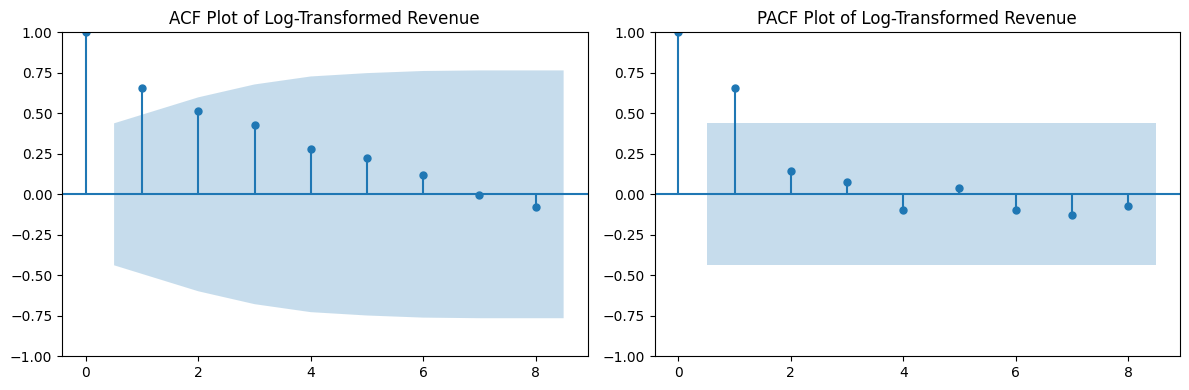

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(stationary_series, ax=axes[0], lags=safe_lags)
axes[0].set_title("ACF Plot of Log-Transformed Revenue")

plot_pacf(stationary_series, ax=axes[1], lags=safe_lags, method="ywm")
axes[1].set_title("PACF Plot of Log-Transformed Revenue")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_acf_pacf_log_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

The ACF and PACF plots were created on the stationary log-transformed revenue series.

The PACF plot shows a strong spike at lag 1, while later lags mostly fall within the confidence interval. This suggests that an autoregressive term of order 1 may be useful.

The ACF plot also shows stronger autocorrelation at the first lag and then gradually weakens. Therefore, possible ARIMA models may include p = 1 and q values around 0 or 1.

However, instead of selecting p and q only by visual inspection, ARIMA grid search will be used to choose the best model based on AIC.

## 12. Train-Test Split

The last 3 months are used as the test set.

A 3-month test set is used because the monthly dataset is short.


In [12]:
TEST_MONTHS = 3

train_original = revenue.iloc[:-TEST_MONTHS]
test_original = revenue.iloc[-TEST_MONTHS:]

train_log = log_revenue.iloc[:-TEST_MONTHS]
test_log = log_revenue.iloc[-TEST_MONTHS:]

print("Training period:", train_original.index.min().date(), "to", train_original.index.max().date())
print("Testing period :", test_original.index.min().date(), "to", test_original.index.max().date())

print("Training months:", len(train_original))
print("Testing months:", len(test_original))

Training period: 2017-01-01 to 2018-05-01
Testing period : 2018-06-01 to 2018-08-01
Training months: 17
Testing months: 3


## 13. ARIMA Grid Search

Instead of manually choosing `p`, `d`, and `q`, we perform grid search.

The model is trained on the **log-transformed revenue** series.  
Forecasts are later converted back using inverse transformation.


In [13]:
p_values = range(0, 4)
d_values = [0]   # log-transformed revenue is already stationary
q_values = range(0, 4)

grid_results = []

for p, d, q in itertools.product(p_values, d_values, q_values):
    if p == 0 and d == 0 and q == 0:
        continue
    
    try:
        model = ARIMA(train_log.astype(float), order=(p, d, q))
        fitted_model = model.fit()
        
        grid_results.append({
            "p": p,
            "d": d,
            "q": q,
            "order": f"ARIMA({p},{d},{q})",
            "AIC": fitted_model.aic,
            "BIC": fitted_model.bic
        })
        
    except Exception as e:
        continue

arima_grid_results = (
    pd.DataFrame(grid_results)
    .sort_values("AIC")
    .reset_index(drop=True)
)

arima_grid_results.head(10)

,p,d,q,order,AIC,BIC
0,1,0,0,"ARIMA(1,0,0)",14.21,16.71
1,1,0,2,"ARIMA(1,0,2)",14.78,18.94
2,2,0,2,"ARIMA(2,0,2)",15.06,20.06
3,3,0,1,"ARIMA(3,0,1)",15.32,20.32
4,3,0,0,"ARIMA(3,0,0)",15.84,20.01
5,2,0,0,"ARIMA(2,0,0)",16.21,19.54
6,1,0,1,"ARIMA(1,0,1)",16.21,19.54
7,3,0,2,"ARIMA(3,0,2)",17.91,23.74
8,2,0,1,"ARIMA(2,0,1)",18.03,22.20
9,2,0,3,"ARIMA(2,0,3)",18.74,24.58


In [14]:
best_order_row = arima_grid_results.iloc[0]

best_p = int(best_order_row["p"])
best_d = int(best_order_row["d"])
best_q = int(best_order_row["q"])

best_order = (best_p, best_d, best_q)

print("Best ARIMA order based on AIC:", best_order)
print("Best model:", best_order_row["order"])
print("AIC:", round(best_order_row["AIC"], 2))

Best ARIMA order based on AIC: (1, 0, 0)
Best model: ARIMA(1,0,0)
AIC: 14.21


The ARIMA grid search shows that ARIMA(1,0,0) has the lowest AIC value among the tested models.

Since the log-transformed revenue series is already stationary, d is fixed at 0.  
The selected model contains one autoregressive term, which means current monthly log revenue is mainly influenced by the previous month’s log revenue.

This result is also supported by the PACF plot, where lag 1 showed the strongest signal.

### Why AIC is Used

AIC helps compare ARIMA models by balancing goodness of fit and model complexity.

Lower AIC means the model explains the data well without becoming unnecessarily complex.


## 14. Fit Best ARIMA Model

The best ARIMA model from grid search is fitted on the training data.


In [15]:
best_arima_model = ARIMA(train_log.astype(float), order=best_order)
best_arima_fit = best_arima_model.fit()

print(best_arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:          total_revenue   No. Observations:                   17
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  -4.105
Date:                Thu, 02 Jul 2026   AIC                             14.210
Time:                        20:56:04   BIC                             16.710
Sample:                    01-01-2017   HQIC                            14.458
                         - 05-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.0038      0.845     15.394      0.000      11.348      14.659
ar.L1          0.9505      0.109      8.731      0.000       0.737       1.164
sigma2         0.0827      0.034      2.409      0.0

## 14. Model Interpretation and Residual Diagnostic Check

The ARIMA grid search selected ARIMA(1,0,0) as the best model based on the lowest AIC value.

The model was fitted on the log-transformed revenue series because the log transformation made the original revenue series stationary.

Before using the model for forecasting, residual diagnostics are checked.  
The purpose is to confirm whether the model has captured most of the time-dependent pattern in the series.

Ideally, residuals should behave like random noise, without strong autocorrelation or visible patterns.

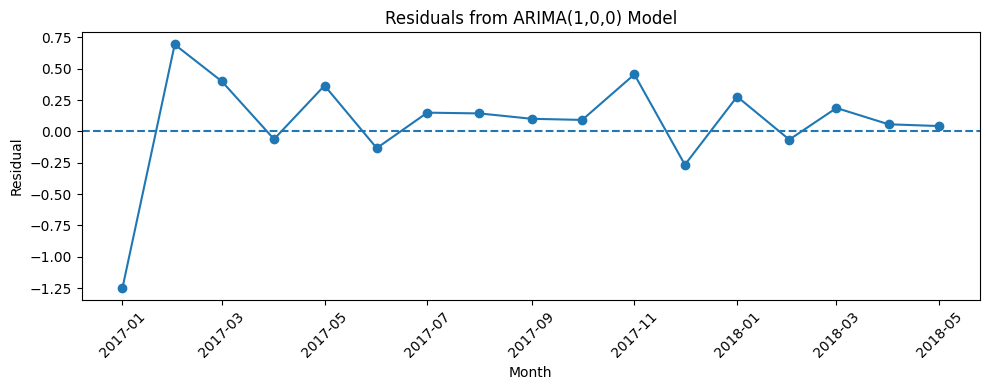

In [16]:
residuals = best_arima_fit.resid

plt.figure(figsize=(10, 4))
plt.plot(residuals, marker="o")
plt.axhline(0, linestyle="--")
plt.title("Residuals from ARIMA(1,0,0) Model")
plt.xlabel("Month")
plt.ylabel("Residual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_arima_residuals.png", dpi=300, bbox_inches="tight")
plt.show()

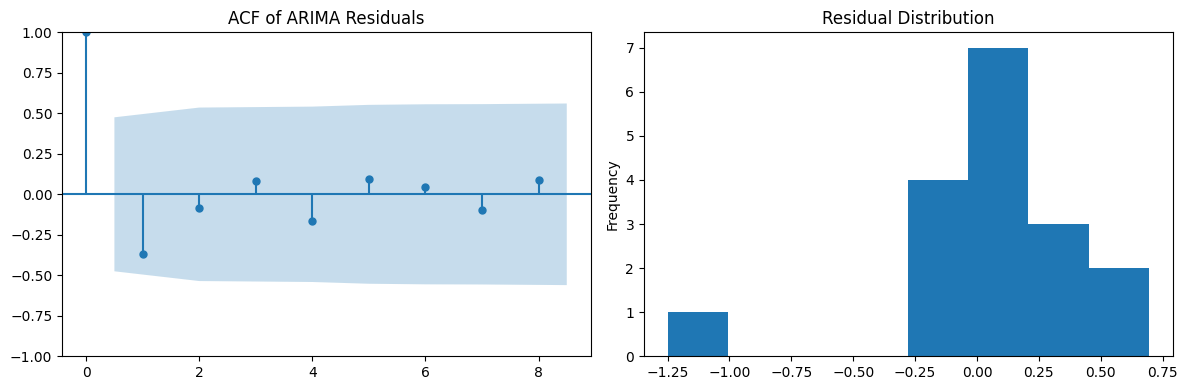

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(residuals, ax=axes[0], lags=min(8, len(residuals)//2))
axes[0].set_title("ACF of ARIMA Residuals")

residuals.plot(kind="hist", bins=8, ax=axes[1])
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_arima_residual_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box_results = acorr_ljungbox(
    residuals,
    lags=[1, 2, 3],
    return_df=True
)

ljung_box_results

,lb_stat,lb_pvalue
1,2.72,0.10
2,2.87,0.24
3,3.03,0.39


The residual diagnostic results show that the ARIMA(1,0,0) model is acceptable for forecasting.

The Ljung-Box test p-values at lags 1, 2, and 3 are greater than 0.05, which means there is no strong evidence of remaining autocorrelation in the residuals.

The residual ACF plot also shows that most residual autocorrelations lie within the confidence interval. Therefore, the residuals behave reasonably like random noise, and the model can be used for forecasting.

## 15. Forecast on Log Scale

The ARIMA forecast is first generated on the transformed log scale.


In [19]:
forecast_log = best_arima_fit.forecast(steps=TEST_MONTHS)
forecast_log.index = test_original.index

forecast_log_df = pd.DataFrame({
    "actual_log_revenue": test_log,
    "forecast_log_revenue": forecast_log
})

forecast_log_df

,actual_log_revenue,forecast_log_revenue
order_month,,
2018-06-01,13.83,13.89
2018-07-01,13.84,13.85
2018-08-01,13.80,13.80


## 16. Inverse Transformation

Since the model was trained on log-transformed revenue, the forecast must be converted back to the original revenue scale.

The inverse of `log1p(x)` is:

`expm1(x) = exp(x) - 1`


In [20]:
forecast_original_scale = np.expm1(forecast_log)
forecast_original_scale = pd.Series(forecast_original_scale, index=test_original.index)

forecast_comparison = pd.DataFrame({
    "actual_revenue": test_original,
    "forecast_revenue": forecast_original_scale
})

forecast_comparison["forecast_error"] = (
    forecast_comparison["actual_revenue"] - forecast_comparison["forecast_revenue"]
)

forecast_comparison["absolute_error"] = forecast_comparison["forecast_error"].abs()

forecast_comparison

,actual_revenue,forecast_revenue,forecast_error,absolute_error
order_month,,,,
2018-06-01,"1,011,978.29","1,077,875.42","-65,897.13","65,897.13"
2018-07-01,"1,027,807.28","1,031,623.11","-3,815.83","3,815.83"
2018-08-01,"985,491.64","989,499.68","-4,008.04","4,008.04"


The ARIMA forecast was converted back from the log scale to the original revenue scale using inverse transformation.

The forecast results show that the model slightly overestimated revenue for all three test months.  
The largest error occurs in June 2018, while July and August forecasts are very close to the actual revenue values.

This indicates that the ARIMA model captures the short-term revenue pattern reasonably well, although some forecast error is still present.

## 17. Forecast Accuracy

The model is evaluated on the test period using:

- MAE,
- RMSE,
- and MAPE.


In [21]:
def mean_absolute_percentage_error(actual, predicted):
    actual = np.array(actual, dtype=float)
    predicted = np.array(predicted, dtype=float)

    mask = actual != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100


mae = mean_absolute_error(test_original, forecast_original_scale)
rmse = np.sqrt(mean_squared_error(test_original, forecast_original_scale))
mape = mean_absolute_percentage_error(test_original, forecast_original_scale)

arima_accuracy = pd.DataFrame({
    "model": [f"ARIMA{best_order} on log revenue"],
    "MAE": [mae],
    "RMSE": [rmse],
    "MAPE_percent": [mape]
})

arima_accuracy

,model,MAE,RMSE,MAPE_percent
0,"ARIMA(1, 0, 0) on log revenue","24,573.67","38,179.65",2.43


The ARIMA(1,0,0) model achieved a MAPE of 2.43% on the test period.

This indicates that the model produced reasonably accurate short-term revenue forecasts for the selected three-month test window.  
The MAE shows that the average absolute forecast error was around 24,574 revenue units, while RMSE is higher because it gives more penalty to the larger June forecast error.

Since the test set contains only three months, the result should be interpreted as short-term forecasting performance rather than a general long-term forecasting guarantee.

## 18. Baseline Comparison

A time series model should be compared with simple baseline models.

We compare ARIMA with:

1. Naive forecast  
2. 3-month moving average forecast  
3. Holt trend model


In [22]:
def naive_forecast(train, steps):
    return pd.Series([train.iloc[-1]] * steps, index=test_original.index)


def moving_average_forecast(train, steps, window=3):
    return pd.Series([train.tail(window).mean()] * steps, index=test_original.index)


naive_pred = naive_forecast(train_original, TEST_MONTHS)
ma3_pred = moving_average_forecast(train_original, TEST_MONTHS, window=3)

holt_model = ExponentialSmoothing(
    train_original.astype(float),
    trend="add",
    seasonal=None,
    initialization_method="estimated"
).fit()

holt_pred = holt_model.forecast(TEST_MONTHS)
holt_pred.index = test_original.index

accuracy_rows = []

for model_name, pred in [
    ("Naive", naive_pred),
    ("Moving Average 3", ma3_pred),
    ("Holt Trend", holt_pred),
    (f"ARIMA{best_order} with log inverse", forecast_original_scale)
]:
    accuracy_rows.append({
        "model": model_name,
        "MAE": mean_absolute_error(test_original, pred),
        "RMSE": np.sqrt(mean_squared_error(test_original, pred)),
        "MAPE_percent": mean_absolute_percentage_error(test_original, pred)
    })

model_accuracy = pd.DataFrame(accuracy_rows).sort_values("MAPE_percent").reset_index(drop=True)

model_accuracy

,model,MAE,RMSE,MAPE_percent
0,"ARIMA(1, 0, 0) with log inverse","24,573.67","38,179.65",2.43
1,Moving Average 3,"118,991.49","120,265.21",11.83
2,Naive,"120,348.78","121,608.29",11.97
3,Holt Trend,"350,987.54","356,809.36",34.90


The baseline comparison shows that the ARIMA(1,0,0) model performs better than the simple benchmark models.

The ARIMA model achieved the lowest MAPE of 2.43%, while the naive and moving average models had errors around 12%.  
The Holt trend model performed poorly, likely because it overextended the trend in a short monthly dataset.

This confirms that the ARIMA model is more suitable for short-term revenue forecasting in this project.

## 19. Actual vs Forecast Plot

This chart compares actual revenue with the inverse-transformed ARIMA forecast and baseline models.


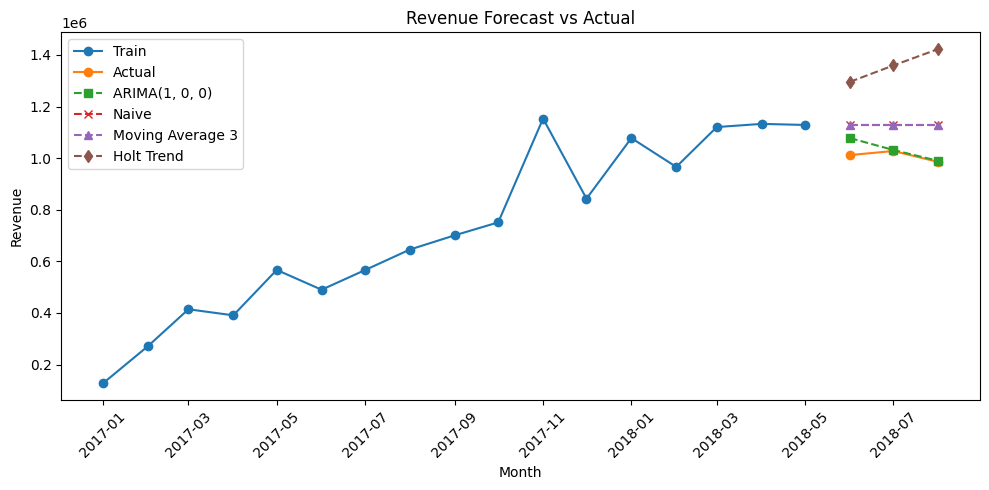

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(train_original.index, train_original.values, label="Train", marker="o")
plt.plot(test_original.index, test_original.values, label="Actual", marker="o")
plt.plot(forecast_original_scale.index, forecast_original_scale.values, label=f"ARIMA{best_order}", marker="s", linestyle="--")
plt.plot(naive_pred.index, naive_pred.values, label="Naive", marker="x", linestyle="--")
plt.plot(ma3_pred.index, ma3_pred.values, label="Moving Average 3", marker="^", linestyle="--")
plt.plot(holt_pred.index, holt_pred.values, label="Holt Trend", marker="d", linestyle="--")

plt.title("Revenue Forecast vs Actual")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_actual_vs_forecast_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

The actual vs forecast plot confirms that the ARIMA(1,0,0) model follows the test-period revenue pattern more closely than the baseline models.

The naive and moving average models produce almost flat forecasts, while the Holt trend model overestimates revenue because it extends the previous upward trend too aggressively.

The ARIMA forecast slightly overestimates revenue but remains closest to the actual values, which supports the earlier model accuracy results.

## 20. Future Forecast

Now we fit the best ARIMA model on the full log-transformed revenue series and forecast the next 3 months.

After forecasting, we apply inverse transformation to return to the original revenue scale.


In [24]:
FUTURE_MONTHS = 3

future_index = pd.date_range(
    start=revenue.index.max() + pd.offsets.MonthBegin(1),
    periods=FUTURE_MONTHS,
    freq="MS"
)

final_model = ARIMA(log_revenue.astype(float), order=best_order)
final_fit = final_model.fit()

future_forecast_log = final_fit.forecast(steps=FUTURE_MONTHS)
future_forecast_log.index = future_index

future_forecast_revenue = np.expm1(future_forecast_log)
future_forecast_revenue = pd.Series(future_forecast_revenue, index=future_index)

future_forecast = pd.DataFrame({
    "forecast_month": future_index,
    "forecast_log_revenue": future_forecast_log.values,
    "forecast_revenue": future_forecast_revenue.values
})

future_forecast["forecast_revenue"] = future_forecast["forecast_revenue"].round(2)

future_forecast

,forecast_month,forecast_log_revenue,forecast_revenue
0,2018-09-01,13.76,"950,342.11"
1,2018-10-01,13.73,"917,929.54"
2,2018-11-01,13.70,"887,993.51"


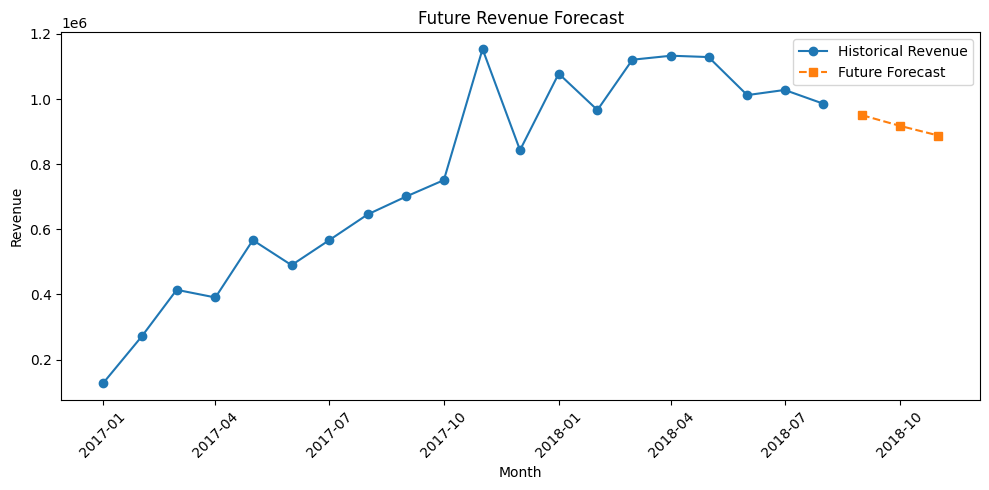

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(revenue.index, revenue.values, label="Historical Revenue", marker="o")
plt.plot(future_forecast["forecast_month"], future_forecast["forecast_revenue"], label="Future Forecast", marker="s", linestyle="--")

plt.title("Future Revenue Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_future_revenue_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

The future forecast gives the expected monthly revenue for the next three months after the available dataset.

The ARIMA model was fitted on the full log-transformed revenue series and then the forecast was converted back to the original revenue scale using inverse transformation.

Since the dataset has limited monthly history, this forecast should be treated as a short-term estimate rather than a long-term business prediction.

## 21. Export Time Series Results

The important outputs are exported for reporting and Power BI.


In [26]:
arima_grid_results.to_csv(REPORTS_DIR / "phase4_arima_grid_search_results.csv", index=False)
model_accuracy.to_csv(REPORTS_DIR / "phase4_model_accuracy.csv", index=False)
forecast_comparison.to_csv(REPORTS_DIR / "phase4_forecast_comparison.csv")
future_forecast.to_csv(REPORTS_DIR / "phase4_future_revenue_forecast.csv", index=False)

print("Saved:", REPORTS_DIR / "phase4_arima_grid_search_results.csv")
print("Saved:", REPORTS_DIR / "phase4_model_accuracy.csv")
print("Saved:", REPORTS_DIR / "phase4_forecast_comparison.csv")
print("Saved:", REPORTS_DIR / "phase4_future_revenue_forecast.csv")

Saved: C:\Users\ayush\OneDrive\Desktop\OlistProject\reports\phase4_arima_grid_search_results.csv
Saved: C:\Users\ayush\OneDrive\Desktop\OlistProject\reports\phase4_model_accuracy.csv
Saved: C:\Users\ayush\OneDrive\Desktop\OlistProject\reports\phase4_forecast_comparison.csv
Saved: C:\Users\ayush\OneDrive\Desktop\OlistProject\reports\phase4_future_revenue_forecast.csv


## 22. Final Interpretation

This phase completed a proper time series forecasting workflow.

The monthly revenue series was first visualized and decomposed.  
Then log transformation was applied to stabilize variance.  
Stationarity was checked before and after transformation, and differencing was applied where required.  
ARIMA parameters were selected using grid search instead of manual guessing.  
Forecasts were generated on the transformed scale and then converted back to the original revenue scale using inverse transformation.

Because the dataset has limited monthly observations, the forecast should be interpreted as a short-term business estimate rather than a long-term seasonal forecast.
